<a href="https://colab.research.google.com/github/RonGopal/intro_to_AI/blob/main/Assignment13rrg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import io
import requests
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
# --- Download a public-domain book from Project Gutenberg ---
GUTENBERG_URL = "https://www.gutenberg.org/files/11/11-0.txt"  # Alice's Adventures in Wonderland

response = requests.get(GUTENBERG_URL, timeout=30)
response.encoding = "utf-8"
raw_text = response.text

def strip_gutenberg_boilerplate(text):
    start_marker = re.search(r"\*\*\* START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", text, re.IGNORECASE)
    end_marker = re.search(r"\*\*\* END OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", text, re.IGNORECASE)
    start = start_marker.end() if start_marker else 0
    end = end_marker.start() if end_marker else len(text)
    return text[start:end].strip()

corpus = strip_gutenberg_boilerplate(raw_text)
corpus = re.sub(r"\r\n", "\n", corpus)
corpus = re.sub(r"\n{3,}", "\n\n", corpus)

print(f"Corpus length: {len(corpus):,} characters")
print("\n--- Sample ---\n")
print(corpus[:500])


Corpus length: 144,529 characters

--- Sample ---

[Illustration]

Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Qua


Total characters : 144,529
Total words       : 26,525
Unique characters : 75
Vocabulary sample : ['\n', ' ', '!', '(', ')', '*', ',', '-', '.', '0', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F']


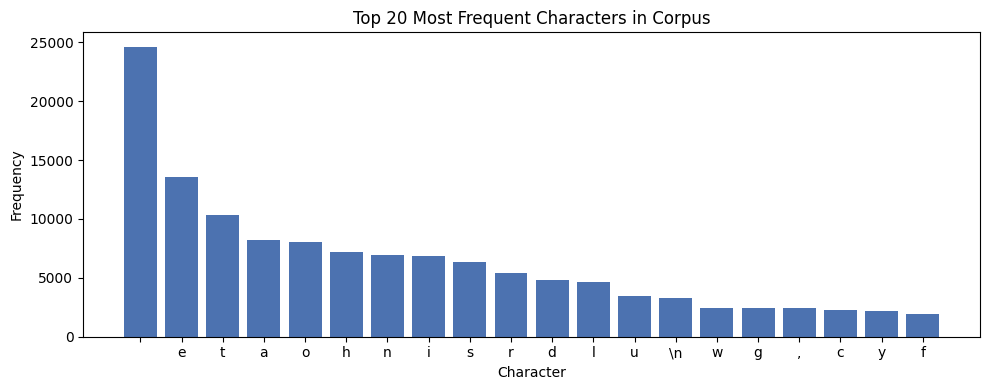

In [3]:
# --- Basic dataset exploration ---
words = corpus.split()
unique_chars = sorted(set(corpus))

print(f"Total characters : {len(corpus):,}")
print(f"Total words       : {len(words):,}")
print(f"Unique characters : {len(unique_chars)}")
print(f"Vocabulary sample : {unique_chars[:20]}")

# Plot character frequency distribution (top 20)
from collections import Counter
char_counts = Counter(corpus)
most_common = char_counts.most_common(20)
labels, counts = zip(*most_common)
labels = [repr(l)[1:-1] for l in labels]  # make whitespace visible

plt.figure(figsize=(10, 4))
plt.bar(labels, counts, color="#4C72B0")
plt.title("Top 20 Most Frequent Characters in Corpus")
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("char_frequency.png", dpi=120)
plt.show()


In [4]:
# --- Build character-level vocabulary & encode the corpus ---
vocab = sorted(set(corpus))
vocab_size = len(vocab)
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for i, ch in enumerate(vocab)}

def encode(text):
    return np.array([char_to_idx[c] for c in text], dtype=np.int32)

def decode(indices):
    return "".join(idx_to_char[int(i)] for i in indices)

encoded_corpus = encode(corpus)
print(f"Vocabulary size: {vocab_size}")
print(f"Encoded corpus length: {len(encoded_corpus):,}")


Vocabulary size: 75
Encoded corpus length: 144,529


In [5]:
# --- Build training sequences (sliding window, next-char prediction) ---
BLOCK_SIZE = 100   # context length (characters)
BATCH_SIZE = 64

def make_dataset(data, block_size, batch_size):
    ds = tf.data.Dataset.from_tensor_slices(data)
    sequences = ds.batch(block_size + 1, drop_remainder=True)

    def split_input_target(chunk):
        return chunk[:-1], chunk[1:]

    dataset = sequences.map(split_input_target)
    dataset = dataset.shuffle(10_000).batch(batch_size, drop_remainder=True)
    return dataset.prefetch(tf.data.AUTOTUNE)

# Use full corpus (small book, so this is fine and trains quickly)
train_dataset = make_dataset(encoded_corpus, BLOCK_SIZE, BATCH_SIZE)
n_batches = tf.data.experimental.cardinality(train_dataset).numpy()
print(f"Number of training batches: {n_batches}")


Number of training batches: 22


In [6]:
# --- Mini-GPT model components ---

class PositionalEmbedding(layers.Layer):
    def __init__(self, block_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_emb = layers.Embedding(input_dim=block_size, output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        return x + self.pos_emb(positions)


class CausalSelfAttentionBlock(layers.Layer):
    """One Transformer decoder block: masked multi-head self-attention + feed-forward,
    each wrapped with a residual connection and layer normalization."""

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn = models.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        # Causal mask: position i can only attend to positions <= i
        causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        attn_out = self.att(query=x, value=x, key=x, attention_mask=causal_mask, training=training)
        x = self.ln1(x + self.drop1(attn_out, training=training))
        ffn_out = self.ffn(x)
        x = self.ln2(x + self.drop2(ffn_out, training=training))
        return x


def build_mini_gpt(vocab_size, block_size, embed_dim=128, num_heads=4, ff_dim=256, num_layers=2, dropout=0.1):
    inputs = layers.Input(shape=(block_size,), dtype=tf.int32)
    x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)
    x = PositionalEmbedding(block_size, embed_dim)(x)
    x = layers.Dropout(dropout)(x)
    for _ in range(num_layers):
        x = CausalSelfAttentionBlock(embed_dim, num_heads, ff_dim, dropout)(x)
    outputs = layers.Dense(vocab_size)(x)  # logits over vocabulary at every position
    return models.Model(inputs=inputs, outputs=outputs, name="mini_gpt")


mini_gpt = build_mini_gpt(vocab_size, BLOCK_SIZE, embed_dim=128, num_heads=4, ff_dim=256, num_layers=2)
mini_gpt.summary()


Model: "mini_gpt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 100, 128)       │        12,800 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ causal_self_attention_block     │ (None, 100, 128)       │       132,480 │
│ (CausalSelfAttentionBlock)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ causal_self_attention_block_1   │ (None, 100, 128)       │       132,480 │
│ (CausalSelfAttentionBlock)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100, 75)        │         9,675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,035 (1.13 MB)

 Trainable params: 297,035 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# --- Compile & train ---
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
mini_gpt.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4), loss=loss_fn)

EPOCHS = 15  # increase for better quality if you have GPU time available

history = mini_gpt.fit(train_dataset, epochs=EPOCHS)


Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 31s 936ms/step - loss: 3.3404
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 798ms/step - loss: 2.7380
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - loss: 2.6166
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - loss: 2.5642
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 884ms/step - loss: 2.5309
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 2.5100
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - loss: 2.4928
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - loss: 2.4772
Epoch 9/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 36s 884ms/step - loss: 2.4646
Epoch 10/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 791ms/step - loss: 2.4503
Epoch 11/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - loss: 2.4366
Epoch 12/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - loss: 2.4229
Epoch 13/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 921ms/step - loss: 2.4113
Epoch 14/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 2.3994
Epoch 15/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 830ms/step - loss: 2.389

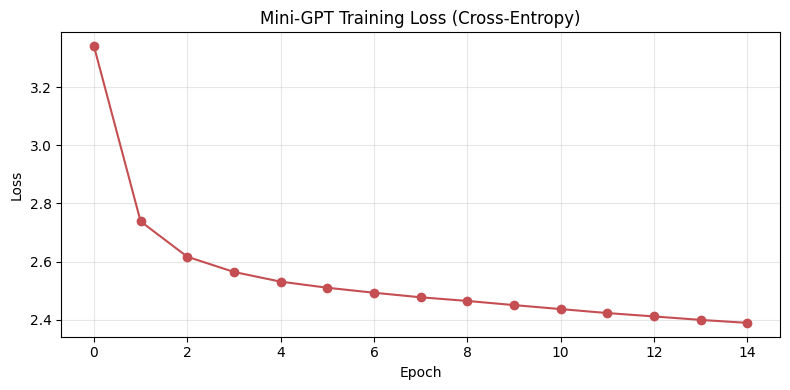

In [8]:
# --- Plot training loss ---
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], marker="o", color="#C44E52")
plt.title("Mini-GPT Training Loss (Cross-Entropy)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=120)
plt.show()


In [9]:
# --- Autoregressive text generation function ---
def generate_text(model, seed_text, num_generate=300, temperature=0.8, block_size=BLOCK_SIZE):
    """Generate text by repeatedly sampling the next character from the model's
    predicted distribution (implements the loop described in Section 3.3)."""
    input_ids = list(encode(seed_text))
    generated = list(input_ids)

    for _ in range(num_generate):
        # Use only the last `block_size` tokens as context, left-padded if shorter
        context = generated[-block_size:]
        pad_len = block_size - len(context)
        padded = [0] * pad_len + context
        x = tf.constant([padded], dtype=tf.int32)

        logits = model(x, training=False)
        next_logits = logits[0, -1, :] / temperature
        probs = tf.nn.softmax(next_logits).numpy()
        next_id = np.random.choice(len(probs), p=probs)
        generated.append(next_id)

    return decode(generated)

sample = generate_text(mini_gpt, seed_text="Alice was ", num_generate=300, temperature=0.7)
print(sample)


Alice was hit hay “We _ wave yoryobomet wonooous y yoout toonou wan dithat s in d thin s ngorereando s tt s the t ben.”



“Than waithirere te pas widond sainon id sangn son hat he t sed s thathe lid rpe wave,” t ar heeeaice Alidore single s


Kicuthet said che adour aing sas the she r uericerey ore d aicous 


In [10]:
def story_continuation_app(prompt, creativity="balanced", length=250):
    """A toy content-creation app: continues a user-supplied prompt using the
    trained mini-GPT, with a simple 'creativity' setting mapped to temperature."""
    temperature_map = {"conservative": 0.4, "balanced": 0.7, "creative": 1.1}
    temperature = temperature_map.get(creativity, 0.7)
    continuation = generate_text(mini_gpt, seed_text=prompt, num_generate=length, temperature=temperature)
    return continuation

# Example use cases
prompts = [
    ("Once upon a time, the Queen ", "conservative"),
    ("The rabbit looked at his watch and ", "balanced"),
    ("Down the rabbit hole, Alice found ", "creative"),
]

for prompt, style in prompts:
    print(f"--- Prompt: {prompt!r} | creativity={style} ---")
    print(story_continuation_app(prompt, creativity=style, length=200))
    print()


--- Prompt: 'Once upon a time, the Queen ' | creativity=conservative ---
Once upon a time, the Queen I’ve at  theatour thare the s youre the t therey  the the there ing and were s we there tore ther on our outhe ate hee thererind wangers t there _ t ather s te s hee outhan are
sing the she thers t he

--- Prompt: 'The rabbit looked at his watch and ' | creativity=balanced ---
The rabbit looked at his watch and war athathe here war gad bin theved thathel s pous ger ato t, of thero arther, pind g ing cher
s anintimuengin therere s thin, y id hasoor seng t Kin te ge aithe o oure one f in inonito ing are heng!”

--- Prompt: 'Down the rabbit hole, Alice found ' | creativity=creative ---
Down the rabbit hole, Alice found he se?” _I’th’sofioo_—whed tie they, shout, o r jus g hanthere s



“Har ihmar. h’s An ased aus in smouroury kne wof of meveare thin igouraneze on fifrmoou whan wond py ded
lin hed, otut! own, beandri



Idea is to predict the next token using everything and self-attention. self-attention lets tokens weigh relevency of earlier token.

training doesn't need manuel labels, each senetence supervisies itself. loss dropped over 15 epochs showing the model was learning

